# 1. Import and Load the data

In [12]:
import pandas as pd
import numpy as np
from IPython.display import display # used to display both info and head in one block

In [13]:
hq = pd.read_csv('https://raw.githubusercontent.com/tabishghouri/Machine-Learning-Project/main/Datasets/consommation-clients-evenements-pointe.csv')
sc = pd.read_csv('https://raw.githubusercontent.com/tabishghouri/Machine-Learning-Project/main/Datasets/25100016.csv')

In [14]:
print('hydro quebec:', hq.shape)
print('statistics canada:', sc.shape)

hydro quebec: (64605, 30)
statistics canada: (37718, 15)


In [15]:
display(hq.head())
display(hq.info())

,Column 1,substation,date,hour,timestamp_local,connected_clients,total_energy_consumed,average_temperature_setpoint,average_inside_temperature,connected_smart_tstats,...,day_of_week,month_cos,month_sin,day_of_week_cos,day_of_week_sin,is_weekend,is_holiday,weekend_holiday,hour_sin,hour_cos
0,60004,B,2023-12-17,14,2023-12-17T14:00:00-05:00,39,105.030781,17.801556,19.823111,259,...,1,1.0,-2.450000e-16,0.62349,0.781831,True,False,True,-0.500000,-0.866025
1,60005,B,2023-12-17,15,2023-12-17T15:00:00-05:00,39,93.582693,17.797478,19.857634,259,...,1,1.0,-2.450000e-16,0.62349,0.781831,True,False,True,-0.707107,-0.707107
2,60007,B,2023-12-17,17,2023-12-17T17:00:00-05:00,39,127.693084,17.858212,19.884531,259,...,1,1.0,-2.450000e-16,0.62349,0.781831,True,False,True,-0.965926,-0.258819
3,60009,B,2023-12-17,19,2023-12-17T19:00:00-05:00,39,116.478204,17.864452,20.016708,259,...,1,1.0,-2.450000e-16,0.62349,0.781831,True,False,True,-0.965926,0.258819
4,60013,B,2023-12-17,23,2023-12-17T23:00:00-05:00,39,63.806577,17.561828,19.870928,259,...,1,1.0,-2.450000e-16,0.62349,0.781831,True,False,True,-0.258819,0.965926


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64605 entries, 0 to 64604
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Column 1                       64605 non-null  int64  
 1   substation                     64605 non-null  object 
 2   date                           64605 non-null  object 
 3   hour                           64605 non-null  int64  
 4   timestamp_local                64605 non-null  object 
 5   connected_clients              64605 non-null  int64  
 6   total_energy_consumed          64605 non-null  float64
 7   average_temperature_setpoint   64605 non-null  float64
 8   average_inside_temperature     64605 non-null  float64
 9   connected_smart_tstats         64605 non-null  int64  
 10  average_solar_radiance         64605 non-null  float64
 11  average_relative_humidity      64605 non-null  int64  
 12  average_snow_precipitation     64605 non-null 

None

In [16]:
display(sc.head())
display(sc.info())

,REF_DATE,GEO,DGUID,"Electric power, components",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2008-01,Canada,2016A000011124,Total generation,Megawatt hours,210,units,0,v44158996,1.1,59082501.0,NaN,NaN,NaN,0
1,2008-01,Canada,2016A000011124,Total receipts,Megawatt hours,210,units,0,v44159003,1.2,1391169.0,NaN,NaN,NaN,0
2,2008-01,Canada,2016A000011124,Purchased receipts from the United States,Megawatt hours,210,units,0,v44159004,1.4,1337651.0,NaN,NaN,NaN,0
3,2008-01,Canada,2016A000011124,Other receipts from the United States,Megawatt hours,210,units,0,v44159005,1.5,53518.0,NaN,NaN,NaN,0
4,2008-01,Canada,2016A000011124,Total deliveries,Megawatt hours,210,units,0,v44159006,1.6,4627072.0,NaN,NaN,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37718 entries, 0 to 37717
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   REF_DATE                    37718 non-null  object 
 1   GEO                         37718 non-null  object 
 2   DGUID                       37718 non-null  object 
 3   Electric power, components  37718 non-null  object 
 4   UOM                         37718 non-null  object 
 5   UOM_ID                      37718 non-null  int64  
 6   SCALAR_FACTOR               37718 non-null  object 
 7   SCALAR_ID                   37718 non-null  int64  
 8   VECTOR                      37718 non-null  object 
 9   COORDINATE                  37718 non-null  float64
 10  VALUE                       25215 non-null  float64
 11  STATUS                      12503 non-null  object 
 12  SYMBOL                      254 non-null    object 
 13  TERMINATED                  0 n

None

# 2. Filtering and Cleaning the data

In [17]:
for c in hq.columns:
  print(f'[{c}]')

[Column 1]
[substation]
[date]
[hour]
[timestamp_local ]
[connected_clients]
[total_energy_consumed ]
[average_temperature_setpoint ]
[average_inside_temperature ]
[connected_smart_tstats ]
[average_solar_radiance]
[average_relative_humidity]
[average_snow_precipitation]
[average_wind_speed]
[average_outside_temperature]
[challenge_type]
[challenge_flag ]
[pre_post_challenge_flag]
[month]
[day]
[day_of_week]
[month_cos]
[month_sin]
[day_of_week_cos]
[day_of_week_sin]
[is_weekend ]
[is_holiday ]
[weekend_holiday]
[hour_sin]
[hour_cos]


In [18]:
# from above code block can see that some columns have trailing spaces, will want to to clean that up
hq.columns = [c.strip() for c in hq.columns]
# sanity check
for c in hq.columns:
  print(f'[{c}]')

[Column 1]
[substation]
[date]
[hour]
[timestamp_local]
[connected_clients]
[total_energy_consumed]
[average_temperature_setpoint]
[average_inside_temperature]
[connected_smart_tstats]
[average_solar_radiance]
[average_relative_humidity]
[average_snow_precipitation]
[average_wind_speed]
[average_outside_temperature]
[challenge_type]
[challenge_flag]
[pre_post_challenge_flag]
[month]
[day]
[day_of_week]
[month_cos]
[month_sin]
[day_of_week_cos]
[day_of_week_sin]
[is_weekend]
[is_holiday]
[weekend_holiday]
[hour_sin]
[hour_cos]


In [19]:
# checking what column 1 even is
print(hq['Column 1'].head(3).tolist()) # just getting the first 3 elem
print(hq['Column 1'].is_unique) # checking if everything in unique
print(hq['Column 1'].min(), hq['Column 1'].max()) # give the lowest and highest elem in column 1

# based on the output, just unique numbers from 0 to 64604 that dont really have a meaning on their own, so we can drop them

[60004, 60005, 60007]
True
0 64604


In [20]:
hq = hq.drop(columns=['Column 1'])
print('Column 1' in hq.columns)

False


In [21]:
print(hq['timestamp_local'].dtype) # checking data type
print(repr(hq['timestamp_local'].iloc[0])) # checking if its just plain text or a proper pandas timestamp

# based on the output, the date is just a string so using dt.hour or something would raise an error
# hq["timestamp_local"].dt.hour

object
'2023-12-17T14:00:00-05:00'


In [22]:
# putting into UTC first because there are offsets like -05:00 and -04:00
hq['timestamp_clean'] = pd.to_datetime(hq['timestamp_local'], utc=True).dt.tz_convert('America/Montreal')
print(hq["timestamp_clean"].dtype)

datetime64[ns, America/Montreal]


In [23]:
# check for duplicates
print(hq.duplicated(['substation', 'timestamp_clean']).sum())

# output 0 so there are no duplicates for each substation

0


In [24]:
print(hq.isna().sum())

substation                          0
date                                0
hour                                0
timestamp_local                     0
connected_clients                   0
total_energy_consumed               0
average_temperature_setpoint        0
average_inside_temperature          0
connected_smart_tstats              0
average_solar_radiance              0
average_relative_humidity           0
average_snow_precipitation          0
average_wind_speed                  0
average_outside_temperature         0
challenge_type                  63888
challenge_flag                      0
pre_post_challenge_flag             0
month                               0
day                                 0
day_of_week                         0
month_cos                           0
month_sin                           0
day_of_week_cos                     0
day_of_week_sin                     0
is_weekend                          0
is_holiday                          0
weekend_holi

In [25]:
# checking to see what the blank values actually mean
print(pd.crosstab(hq['challenge_type'].isna(), hq['challenge_flag']))

# so 717 hours means there was an event happening and its type was recorded
# 63888 hours means there was no event happening, and no type was recorded
# top left: no hour has a type when theres no event
# bottom right: no hour has an event with a missing type
# a blank type only appears when theres no event

# basically, the null values arent missing data, its just means there was no event at this hour

challenge_flag      0    1
challenge_type            
False               0  717
True            63888    0


In [26]:
hq['challenge_type'] = hq['challenge_type'].fillna("None")
print(hq['challenge_type'].value_counts())
print(hq.isna().sum())

challenge_type
None    63888
CPR       705
LCPR       12
Name: count, dtype: int64
substation                      0
date                            0
hour                            0
timestamp_local                 0
connected_clients               0
total_energy_consumed           0
average_temperature_setpoint    0
average_inside_temperature      0
connected_smart_tstats          0
average_solar_radiance          0
average_relative_humidity       0
average_snow_precipitation      0
average_wind_speed              0
average_outside_temperature     0
challenge_type                  0
challenge_flag                  0
pre_post_challenge_flag         0
month                           0
day                             0
day_of_week                     0
month_cos                       0
month_sin                       0
day_of_week_cos                 0
day_of_week_sin                 0
is_weekend                      0
is_holiday                      0
weekend_holiday                 0

In [27]:
# checking count of each substation
hq.groupby('substation').size()

# basically saying all three substations have the same num of rows
# doesnt really tell us if all of that is present with hours

,0
substation,
A,21535
B,21535
C,21535


In [28]:
# want to check how many hours there should be
substation_a = hq[hq['substation'] == "A"].sort_values('timestamp_clean')
full_hours = pd.date_range(substation_a['timestamp_clean'].min(), substation_a['timestamp_clean'].max(), freq='h')
missing_hours = full_hours.difference(substation_a['timestamp_clean'])
print(len(full_hours), len(substation_a), len(missing_hours))

# output tells us that there should be 21887 hours but we have 21535 meaning 352 are missing

21887 21535 352


In [29]:
# want to see if its 352 seperate single hours of if its like a block of hours spanning weeks thats missing
substation_a['timestamp_clean'].diff().value_counts()

# output telling us that most rows 1 hour apart
# 350 times theres a 2 hour gap meaning theres exactly 1 hour missing at that spot
# theres a 3 hour gap so that means at that point two hours are missing

,count
timestamp_clean,
0 days 01:00:00,21183
0 days 02:00:00,350
0 days 03:00:00,1


In [30]:
# want to check which hours are missing
(pd.Series(missing_hours.hour).value_counts().head(3))

# output is saying that 350 of them are midnight

,count
0,350
1,2


In [31]:
# gonna check when these hours are being missed
pd.Series(missing_hours).dt.strftime('%Y-%m').value_counts().sort_index()

# so the missing midnights start in march and stop early nov
# these line up with our daylight savings that we have so probably there was a bug when exporting
# each gap is only an hour so its fine to fill them in by averaging the hours on either side

,count
2022-11,1
2023-03,19
2023-04,30
2023-05,31
2023-06,30
2023-07,31
2023-08,31
2023-09,30
2023-10,31
2023-11,6


In [32]:
# these cols have numbers that change smoothly over time so it makes sense to use them
measure_cols = ['connected_clients', 'total_energy_consumed', 'average_temperature_setpoint',
                'average_inside_temperature', 'connected_smart_tstats', 'average_solar_radiance',
                'average_relative_humidity', 'average_snow_precipitation', 'average_wind_speed',
                'average_outside_temperature']
filled = []

for station in ['A', 'B', 'C']:
  station_df = hq[hq['substation'] == station].set_index('timestamp_clean').sort_index()
  station_df = station_df.asfreq('h') # add missing hours as empty rows
  station_df['was_missing'] = station_df['substation'].isna() # remember which rows we added
  station_df[measure_cols] = station_df[measure_cols].interpolate() # fill numbers with the average of neighbours
  station_df = station_df.ffill() # fill text/flag cols from the hour before
  filled.append(station_df)
hq = pd.concat(filled).reset_index()


/tmp/ipykernel_2120/2638738377.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  station_df = station_df.ffill() # fill text/flag cols from the hour before
/tmp/ipykernel_2120/2638738377.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  station_df = station_df.ffill() # fill text/flag cols from the hour before
/tmp/ipykernel_2120/2638738377.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior

In [33]:
# checking if the fill worked
print(len(hq), hq['was_missing'].sum())
print(hq.groupby('substation').size())

65661 1056
substation
A    21887
B    21887
C    21887
dtype: int64


In [34]:
# checking that there are no blanks
print(hq.isna().sum().sum())

0


In [35]:
# ffil copied the calendar cols form the hour before (11pmm of the previous day)
# checking one of the added rows to see if that caused anything weird
cols = ['timestamp_clean', 'date', 'hour', 'day_of_week', 'is_weekend', 'was_missing']

a = hq[hq['substation'] == 'A']
a[(a['timestamp_clean'] >= '2023-03-12 23:00') & (a['timestamp_clean'] <= '2023-03-13 01:00')][cols]

# row 2 is showing the wrong added values
# it should be showing a midnight monday
# instead its showing an 11pm sunday

,timestamp_clean,date,hour,day_of_week,is_weekend,was_missing
10462,2023-03-12 23:00:00-04:00,2023-03-12,23.0,1.0,True,False
10463,2023-03-13 00:00:00-04:00,2023-03-12,23.0,1.0,True,True
10464,2023-03-13 01:00:00-04:00,2023-03-13,1.0,2.0,False,False


In [36]:
# checking how many added rows have wrong calendar values
m = hq[hq['was_missing']]    # only the rows we added

print((m['hour'] != m['timestamp_clean'].dt.hour).sum(), 'of', len(m), 'have the wrong hour')
print((m['date'] != m['timestamp_clean'].dt.date.astype(str)).sum(), 'have the wrong date')

# output shows that every added hour is the wrong hour and almost all have the wrong date

1056 of 1056 have the wrong hour
1053 have the wrong date


In [37]:
before_fix = hq[['hour', 'day_of_week', 'is_weekend']].copy() # making a copy before fixing for safety

# rebuilding the calendar columns form the timestamp
hq['date'] = hq['timestamp_clean'].dt.date.astype(str)
hq['hour'] = hq['timestamp_clean'].dt.hour
hq['day'] = hq['timestamp_clean'].dt.day
hq['month'] = hq['timestamp_clean'].dt.month
hq['day_of_week'] = (hq['timestamp_clean'].dt.dayofweek + 1) % 7 + 1 # pandas has monday = 0, dataset has sunday = 1
hq['is_weekend'] = hq['day_of_week'].isin([1, 7]) # sunday or saturday

'''
want to use sin cos version of hour, day of week and month
hour 23 which is 11 pm and hour 0 which is midnight look like there 23 apart
even though theyre really just 1 hour apart
same thing can be applied with sunday and saturday being 7 apart even thouugh theyre really one day apart
and december and jan being 12 apart even though theyre really just one month apart if your start from dec

so its alot easier to just put these numbers on a circle
and use cos and sin to describe their positions
cos would be how far up/down it is on the circle
sin would be how far left/right it is on the circle
so like 11pm and 12am would be get similar sin/cos values

so we would do hour / 24 to see how far around the circle we are
then do * 2 * pi to get an angle
then do np.sin or np.cos to turn that angle into up/down or left/right
this same idea can also be used for week and month but with 7 and 12 instead

its like sin 0 and cos 1 would represent midnight which is the top of the clock
and sin 0 and cos -1 would be noon which is the bottom of the clock

we just have to recalc all this stuff because the added midnight rows copied 11pm's values when we did ffill
'''

hq['hour_sin'] = np.sin(2 * np.pi * hq['hour'] / 24)
hq['hour_cos'] = np.cos(2 * np.pi * hq['hour'] / 24)
hq['day_of_week_sin'] = np.sin(2 * np.pi * hq['day_of_week'] / 7)
hq['day_of_week_cos'] = np.cos(2 * np.pi * hq['day_of_week'] / 7)
hq['month_sin'] = np.sin(2 * np.pi * hq['month'] / 12)
hq['month_cos'] = np.cos(2 * np.pi * hq['month'] / 12)

In [38]:
# checking to see if its good now
cols = ['timestamp_clean', 'date', 'hour', 'day_of_week', 'is_weekend', 'was_missing']

a = hq[hq['substation'] == 'A']
a[(a['timestamp_clean'] >= '2023-03-12 23:00') & (a['timestamp_clean'] <= '2023-03-13 01:00')][cols]

,timestamp_clean,date,hour,day_of_week,is_weekend,was_missing
10462,2023-03-12 23:00:00-04:00,2023-03-12,23,1,True,False
10463,2023-03-13 00:00:00-04:00,2023-03-13,0,2,False,True
10464,2023-03-13 01:00:00-04:00,2023-03-13,1,2,False,False


In [39]:
# need to apply same type of logic to holidays
# since holidays apply for the whole day all 24 hours should have the is_holiday value
cols = ['timestamp_clean', 'date', 'is_holiday', 'was_missing']

a = hq[hq['substation'] == 'A']
a[(a['timestamp_clean'] >= '2023-06-30 22:00') & (a['timestamp_clean'] <= '2023-07-01 02:00')][cols]

# showing the added row of jul 1 is false, even tho it is a holiday
# means it copied false from jun 30 when we did ffill

,timestamp_clean,date,is_holiday,was_missing
13101,2023-06-30 22:00:00-04:00,2023-06-30,False,False
13102,2023-06-30 23:00:00-04:00,2023-06-30,False,False
13103,2023-07-01 00:00:00-04:00,2023-07-01,False,True
13104,2023-07-01 01:00:00-04:00,2023-07-01,True,False
13105,2023-07-01 02:00:00-04:00,2023-07-01,True,False


In [40]:
# counting the is_holiday values for all 24 hours of canada day
a[a['date'] == '2023-07-01']['is_holiday'].value_counts()

# output shows the 1 false added midnight row

,count
is_holiday,
True,23
False,1


In [41]:
# every hour of the day should agree on is_holiday so each day should have 1 unique val
holiday_per_day = hq.groupby(['substation', 'date'])['is_holiday'].nunique()

print((holiday_per_day > 1).sum(), 'days have both True and False')
holiday_per_day[holiday_per_day > 1].head(6)

# 54 days where the hours disagree
# for example on good friday 2023-04-07 and the day after
# on the holiday, midnight copied False from the normal day before it
# and on the day after, midnight copied True from the holiday before it

54 days have both True and False


substation  date      
A           2023-04-07    2
            2023-04-08    2
            2023-05-22    2
            2023-05-23    2
            2023-06-24    2
            2023-06-25    2
Name: is_holiday, dtype: int64

In [42]:
# cant rely on panadas to know what is holiday based on the date
# so blank out the added rows since they were copied from the wrong day
hq.loc[hq['was_missing'], 'is_holiday'] = np.nan

# then group by substation and day
# take the max of that days values since blanks are skipped
# and put it into every row of that day
hq['is_holiday'] = hq.groupby(['substation', 'date'])['is_holiday'].transform('max').astype(bool)
hq['weekend_holiday'] = hq['is_weekend'] | hq['is_holiday']

/tmp/ipykernel_2120/1634906979.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  hq.loc[hq['was_missing'], 'is_holiday'] = np.nan


In [43]:
holiday_per_day = hq.groupby(['substation', 'date'])['is_holiday'].nunique()
print((holiday_per_day > 1).sum(), 'days have both True and False')

0 days have both True and False


In [44]:
# check again
a = hq[hq['substation'] == 'A']
display(a[(a['timestamp_clean'] >= '2023-06-30 22:00') & (a['timestamp_clean'] <= '2023-07-01 02:00')][cols])

# and the day after canada day, midnight should be False (it used to copy True from jul 1)
display(a[(a['timestamp_clean'] >= '2023-07-01 22:00') & (a['timestamp_clean'] <= '2023-07-02 01:00')][cols])

,timestamp_clean,date,is_holiday,was_missing
13101,2023-06-30 22:00:00-04:00,2023-06-30,False,False
13102,2023-06-30 23:00:00-04:00,2023-06-30,False,False
13103,2023-07-01 00:00:00-04:00,2023-07-01,True,True
13104,2023-07-01 01:00:00-04:00,2023-07-01,True,False
13105,2023-07-01 02:00:00-04:00,2023-07-01,True,False


,timestamp_clean,date,is_holiday,was_missing
13125,2023-07-01 22:00:00-04:00,2023-07-01,True,False
13126,2023-07-01 23:00:00-04:00,2023-07-01,True,False
13127,2023-07-02 00:00:00-04:00,2023-07-02,False,True
13128,2023-07-02 01:00:00-04:00,2023-07-02,False,False


In [45]:
hq['total_energy_consumed'].describe()

,total_energy_consumed
count,65661.000000
mean,149.677769
std,190.430903
min,7.450200
25%,61.228537
50%,109.099919
75%,193.938759
max,32240.173270


In [46]:
# looking at the 5 biggest values
hq.nlargest(5, 'total_energy_consumed')[['substation', 'timestamp_clean', 'total_energy_consumed']]

# seeing the top 3 are august, kinda weird they should be showing winter months

,substation,timestamp_clean,total_energy_consumed
5316,A,2022-08-10 13:00:00-04:00,32240.173270
48954,C,2022-08-04 21:00:00-04:00,11804.198070
27006,B,2022-08-02 08:00:00-04:00,8890.272607
44047,C,2022-01-12 09:00:00-05:00,4294.100203
51779,C,2022-11-30 13:00:00-05:00,3176.001378


In [47]:
a = hq[hq['substation'] == 'A']
a[(a['timestamp_clean'] >= '2022-08-10 10:00') & (a['timestamp_clean'] <= '2022-08-10 16:00')][['timestamp_clean', 'total_energy_consumed']]

# going from ~34 to ~36 to ~33 and then all of a sudden 32240 and then back to ~27
# doing that big of a jump in a single hour is probably a logging error

,timestamp_clean,total_energy_consumed
5313,2022-08-10 10:00:00-04:00,33.968845
5314,2022-08-10 11:00:00-04:00,36.287108
5315,2022-08-10 12:00:00-04:00,32.630352
5316,2022-08-10 13:00:00-04:00,32240.173270
5317,2022-08-10 14:00:00-04:00,27.047453
5318,2022-08-10 15:00:00-04:00,27.096060
5319,2022-08-10 16:00:00-04:00,33.382245


In [48]:
# finding all spikes by comparing the hour before and after they happen
before = hq.groupby('substation')['total_energy_consumed'].shift(1)
after = hq.groupby('substation')['total_energy_consumed'].shift(-1)
neighbours = (before + after) / 2

check = pd.DataFrame({'time': hq['timestamp_clean'], 'energy': hq['total_energy_consumed'],
                      'before': before, 'after': after, 'neighbours_avg': neighbours})
check[(hq['substation'] == 'A') & (hq['timestamp_clean'] >= '2022-08-10 12:00') & (hq['timestamp_clean'] <= '2022-08-10 14:00')]

,time,energy,before,after,neighbours_avg
5315,2022-08-10 12:00:00-04:00,32.630352,36.287108,32240.173270,16138.230189
5316,2022-08-10 13:00:00-04:00,32240.173270,32.630352,27.047453,29.838902
5317,2022-08-10 14:00:00-04:00,27.047453,32240.173270,27.096060,16133.634665


In [49]:
spike = hq['total_energy_consumed'] > 5 * neighbours # checking for ones that are 5x more than avg of its neighbours
print(spike.sum(), 'spikes found')

21 spikes found


In [50]:
# looking at every flagged row before changing stuff to see if there really errors
flagged = hq[spike][['substation', 'timestamp_clean', 'total_energy_consumed']].copy()
flagged['neighbours_avg'] = neighbours[spike]
flagged.sort_values('total_energy_consumed', ascending=False)

,substation,timestamp_clean,total_energy_consumed,neighbours_avg
5316,A,2022-08-10 13:00:00-04:00,32240.173270,29.838902
48954,C,2022-08-04 21:00:00-04:00,11804.198070,145.478285
27006,B,2022-08-02 08:00:00-04:00,8890.272607,51.056262
44047,C,2022-01-12 09:00:00-05:00,4294.100203,400.336534
51779,C,2022-11-30 13:00:00-05:00,3176.001378,387.910323
9490,A,2023-01-31 10:00:00-05:00,2178.885505,257.223099
29218,B,2022-11-02 12:00:00-04:00,2166.458603,60.800204
28909,B,2022-10-20 15:00:00-04:00,2133.456467,77.919851
45584,C,2022-03-17 11:00:00-04:00,1908.344495,197.859582
29582,B,2022-11-17 15:00:00-05:00,1775.088332,153.127439


In [51]:
# gonna replace the spikes same way we did the hours by using avg of the neighbours
rows_before = len(hq)
hq['spike_fixed'] = spike

hq.loc[spike, 'total_energy_consumed'] = np.nan

for station in ['A', 'B', 'C']:
  rows = hq['substation'] == station
  hq.loc[rows, 'total_energy_consumed'] = hq.loc[rows, 'total_energy_consumed'].interpolate()


In [52]:
hq['total_energy_consumed'].describe()

,total_energy_consumed
count,65661.000000
mean,148.470087
std,128.477553
min,7.450200
25%,61.212736
50%,109.078189
75%,193.830805
max,1414.907335


In [53]:
# checking before spike
a = hq[hq['substation'] == 'A']
a[(a['timestamp_clean'] >= '2022-08-10 10:00') & (a['timestamp_clean'] <= '2022-08-10 16:00')][['timestamp_clean', 'total_energy_consumed', 'spike_fixed']]

,timestamp_clean,total_energy_consumed,spike_fixed
5313,2022-08-10 10:00:00-04:00,33.968845,False
5314,2022-08-10 11:00:00-04:00,36.287108,False
5315,2022-08-10 12:00:00-04:00,32.630352,False
5316,2022-08-10 13:00:00-04:00,29.838902,True
5317,2022-08-10 14:00:00-04:00,27.047453,False
5318,2022-08-10 15:00:00-04:00,27.096060,False
5319,2022-08-10 16:00:00-04:00,33.382245,False


In [54]:
# checking if other cols have good ranges
hq[['average_outside_temperature', 'average_inside_temperature', 'average_temperature_setpoint',
    'average_relative_humidity', 'average_wind_speed', 'average_solar_radiance',
    'average_snow_precipitation']].agg(['min', 'max'])

,average_outside_temperature,average_inside_temperature,average_temperature_setpoint,average_relative_humidity,average_wind_speed,average_solar_radiance,average_snow_precipitation
min,-32.000000,16.210841,9.315278,16.0,0.00,0.0,0.0
max,35.200001,27.084625,21.032967,100.0,15.68,961.0,306.0


In [55]:
# looking at biggest snow values
hq.nlargest(6, 'average_snow_precipitation')[['substation', 'timestamp_clean', 'average_snow_precipitation']]

,substation,timestamp_clean,average_snow_precipitation
16566,A,2023-11-22 06:00:00-05:00,306.0
38453,B,2023-11-22 06:00:00-05:00,306.0
60340,C,2023-11-22 06:00:00-05:00,306.0
8857,A,2023-01-05 01:00:00-05:00,200.0
30744,B,2023-01-05 01:00:00-05:00,200.0
52631,C,2023-01-05 01:00:00-05:00,200.0


In [56]:
# checking the names
# we only need quebec so gonna filter for that
print(sc['GEO'].unique())
print(sc['Electric power, components'].unique())

['Canada' 'Newfoundland and Labrador' 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia' 'Yukon' 'Northwest Territories' 'Nunavut']
['Total generation' 'Total receipts'
 'Purchased receipts from the United States'
 'Other receipts from the United States' 'Total deliveries'
 'Deliveries to the United States' 'Total firm deliveries'
 'Firm deliveries to the United States' 'Total non-firm deliveries'
 'Non-firm deliveries to the United States' 'Total other deliveries'
 'Other deliveries to the United States'
 'Total electricity available for use within specific geographic border'
 'Receipts from other provinces' 'Deliveries to other provinces'
 'Firm deliveries to other provinces'
 'Non-firm deliveries to other provinces']


In [57]:
sc_quebec = sc[(sc['GEO'] == 'Quebec') &
               (sc['Electric power, components'] == 'Total electricity available for use within specific geographic border')]

sc_quebec = sc_quebec[['REF_DATE', 'VALUE']].copy() # only need month and number
sc_quebec['REF_DATE'] = pd.to_datetime(sc_quebec['REF_DATE']) # turning the text into real date

print(len(sc_quebec), 'months')
print(sc_quebec['VALUE'].isna().sum(), 'missing values')
print(sc_quebec['REF_DATE'].min(), 'to', sc_quebec['REF_DATE'].max())
sc_quebec.head()

223 months
0 missing values
2008-01-01 00:00:00 to 2026-07-01 00:00:00


,REF_DATE,VALUE
80,2008-01-01,21057633.0
248,2008-02-01,20515908.0
416,2008-03-01,20238085.0
584,2008-04-01,16380037.0
752,2008-05-01,15028633.0


In [58]:
# final check on hq
print(hq.shape)
print(hq.isna().sum().sum(), 'blanks')
print(hq['was_missing'].sum(), 'rows added (missing hours)')
print(hq['spike_fixed'].sum(), 'values replaced (spikes)')
print(hq.duplicated(['substation', 'timestamp_clean']).sum(), 'duplicates')

(65661, 32)
0 blanks
1056 rows added (missing hours)
21 values replaced (spikes)
0 duplicates


In [59]:
hq.to_csv('hq_cleaned.csv', index=False)
sc_quebec.to_csv('sc_monthly_quebec.csv', index=False)

In [60]:
import matplotlib.pyplot as plt

# Figure 1: Average electricity use in Quebec by month
Will be using Statistics Canada data

In [61]:
sc_quebec['month'] = sc_quebec['REF_DATE'].dt.month # pulling the month number out of the date basically

# gonna group all jans, febs, etc and get the avg
# gonna turn MWh into TWh so its easier to read
monthly_avg = sc_quebec.groupby('month')['VALUE'].mean() / 1_000_000
monthly_avg.round(1)

,VALUE
month,
1,23.3
2,20.7
3,20.2
4,16.6
5,14.9
6,14.1
7,14.8
8,14.6
9,14.0


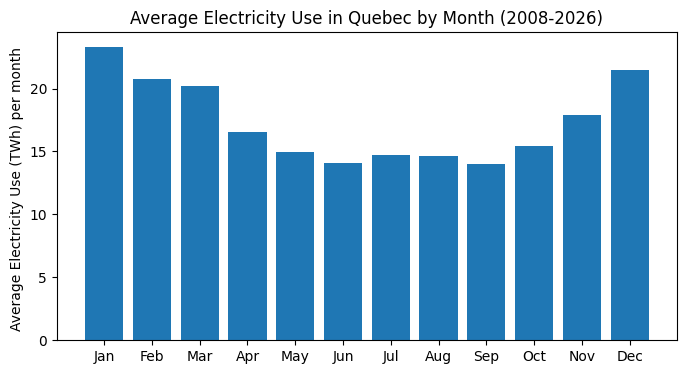

'\njan is the highest\nsept is the lowest\ndec, jan, feb are the highest months\nconfirms winter is when quebec uses most electricity\n'

In [62]:
plt.figure(figsize=(8, 4))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Average Electricity Use (TWh) per month ')
plt.title('Average Electricity Use in Quebec by Month (2008-2026)')
plt.show()

'''
jan is the highest
sept is the lowest
dec, jan, feb are the highest months
confirms winter is when quebec uses most electricity
'''

# Figure 2: Daily energy use per customer at each substation

In [63]:
# each substation has diff num of customers
# one substation might look bigger but doesnt really mean its using more
# so want to get energy per customer

hq['energy_per_client'] = hq['total_energy_consumed'] / hq['connected_clients']

daily = hq.groupby(['substation', 'date'])['energy_per_client'].sum().reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily.head()


,substation,date,energy_per_client
0,A,2022-01-01,114.225125
1,A,2022-01-02,139.676973
2,A,2022-01-03,191.945637
3,A,2022-01-04,191.774892
4,A,2022-01-05,137.556036


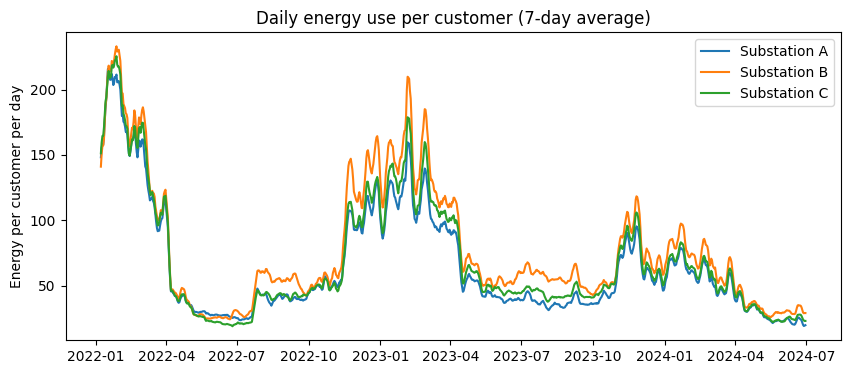

In [64]:
plt.figure(figsize=(10, 4))
for station in ['A', 'B', 'C']:
  station_daily = daily[daily['substation'] == station]
  plt.plot(station_daily['date'], station_daily['energy_per_client'].rolling(7).mean(), label=f'Substation {station}') #
plt.ylabel('Energy per customer per day')
plt.title('Daily energy use per customer (7-day average)')
plt.legend()
plt.show()


# all substations show a big peak every winter and a small peak every summer


# Figure 3: Hourly energy use vs outdoor temperature

In [65]:
# checking how strongly correlated outdoor temp and energy use are
print(hq['average_outside_temperature'].corr(hq['energy_per_client']))

# shows a strong neg correlation so the colder it is the more energy being used which makes sense

-0.6982833422653165


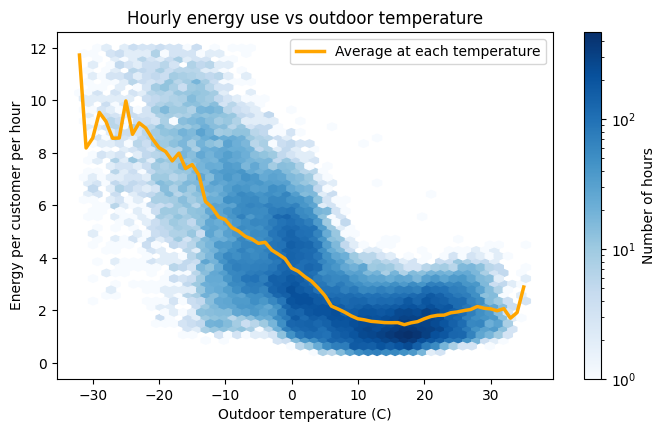

In [66]:
plt.figure(figsize=(8, 4.5))

hb = plt.hexbin(hq['average_outside_temperature'], hq['energy_per_client'],
                gridsize=50, cmap='Blues', mincnt=1, bins='log', extent=(-32, 36, 0, 12))
plt.colorbar(hb, label='Number of hours')

temp_rounded = hq['average_outside_temperature'].round()
avg_by_temp = hq.groupby(temp_rounded)['energy_per_client'].mean()

plt.plot(avg_by_temp.index, avg_by_temp.values, color='orange', linewidth=2.5, label='Average at each temperature')

plt.xlabel('Outdoor temperature (C)')
plt.ylabel('Energy per customer per hour')
plt.title('Hourly energy use vs outdoor temperature')
plt.legend(loc='upper right')
plt.show()

# Figure 4: Avergae winter day vs Hilo event day

In [67]:
# comparing normal winter day to Hilo event day
hq['event_day'] = hq.groupby(['substation', 'date'])['challenge_flag'].transform('max') == 1

winter = hq[hq['month'].isin([12,1,2])]

normal_day = winter[~winter['event_day']].groupby('hour')['energy_per_client'].mean()
event_day = winter[winter['event_day']].groupby('hour')['energy_per_client'].mean()

print(winter[winter['event_day']]['date'].nunique(), 'winter event day')
pd.DataFrame({'normal_day': normal_day, 'event_day': event_day}).round(2)

43 winter event day


,normal_day,event_day
hour,,
0,3.94,3.77
1,3.90,4.10
2,3.91,4.10
3,4.02,4.27
4,4.44,6.45
5,4.82,5.87
6,5.35,2.66
7,5.74,2.51
8,5.70,2.56


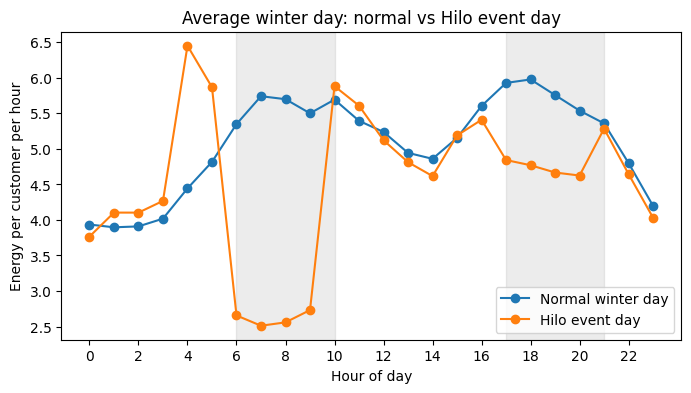

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(normal_day.index, normal_day.values, marker='o', label='Normal winter day')
plt.plot(event_day.index, event_day.values, marker='o', label='Hilo event day')

# shading the hilo event windows (6-10am and 5-9pm) so its easy to see where the events are
plt.axvspan(6, 10, alpha=0.15, color='gray')
plt.axvspan(17, 21, alpha=0.15, color='gray')

plt.xticks(range(0, 24, 2))
plt.xlabel('Hour of day')
plt.ylabel('Energy per customer per hour')
plt.title('Average winter day: normal vs Hilo event day')
plt.legend()
plt.show()

In [69]:
target = 'energy_per_client'
hq[target].describe()

,energy_per_client
count,65661.000000
mean,2.942753
std,2.123193
min,0.340510
25%,1.454856
50%,2.260048
75%,3.781003
max,33.128652


In [72]:
# checking how much memory the cleaned data takes up
print(hq.shape)
print(round(hq.memory_usage(deep=True).sum() / 1_000_000, 1), 'MB')

(65661, 34)
27.4 MB


# Sample Input and Output

In [70]:
# example hours from substation A on feb 7 2023, a winter day with a morning hilo event
# 5am = pre-heating, 7am = during the event, 10am = recovery
example_times = pd.to_datetime(['2023-02-07 05:00', '2023-02-07 07:00', '2023-02-07 10:00']).tz_localize('America/Montreal')
example = hq[(hq['substation'] == 'A') & (hq['timestamp_clean'].isin(example_times))]

example[['timestamp_clean', 'average_outside_temperature', 'connected_clients',
         'pre_post_challenge_flag', 'challenge_flag', target]]


,timestamp_clean,average_outside_temperature,connected_clients,pre_post_challenge_flag,challenge_flag,energy_per_client
9653,2023-02-07 05:00:00-05:00,-17.799999,52.0,1.0,0.0,7.624718
9655,2023-02-07 07:00:00-05:00,-14.700000,52.0,0.0,1.0,2.520260
9658,2023-02-07 10:00:00-05:00,-12.900000,52.0,1.0,0.0,7.438773
